# Q.6 Principal Component Analysis (PCA)
In this task, we will implement PCA in Python to understand its importance as an unsupervised learning method. The goal is to reproduce patterns similar to Figure 1 of the referenced paper using the provided dataset.

### Dataset Details:
- **data/class.tsv**: Contains labels (1 for ER+ breast cancer, 0 for ER- breast cancer).
- **data/filtered.tsv.gz**: Complete dataset with gene expression values. The header contains gene IDs.
- **data/columns.tsv.gz**: Mapping of gene IDs to gene names.

### Objectives:
1. Extract expression levels of genes **XBP1** and **GATA3** for all 105 patients and generate a scatter plot (similar to Figure 1a). Color the points based on the class labels.
2. Perform PCA on the dataset and project the data onto the first principal component (PC1). Generate a plot similar to Figure 1c.

### Key Insights:
- PCA helps reduce dimensionality while preserving important patterns.
- Visualizing gene expression data in 2D space can reveal meaningful biological insights.

In [31]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

In [32]:
# Load class labels
class_labels = pd.read_csv('class.tsv', sep='\t', header=None)
labels = class_labels[0].values

# Load gene ID to gene name mapping
with open('columns.tsv', 'rt') as f:
    lines = [line for line in f if not line.startswith('#')]

temp = StringIO(''.join(lines))
gene_map = pd.read_csv(temp, sep='\t')

# Load gene expression data
with open('filtered.tsv', 'rt') as f:
    gene_data = pd.read_csv(f, sep='\t', index_col=0)

gene_data.columns = gene_data.columns.astype(str).str.strip()

# Find gene IDs for XBP1 and GATA3
xbp1_id = 4404
gata3_id = gene_map[gene_map['GeneSymbol'] == 'GATA3']['ID'].values[0]

# Extract expression levels
xbp1_expression = gene_data[str(xbp1_id)].values
gata3_expression = gene_data[str(gata3_id)].values

print(f"GATA3 ID: {gata3_id}, XBP1 ID: {xbp1_id}")
colors = ['blue' if label == 0 else 'red' for label in labels]

GATA3 ID: 4359, XBP1 ID: 4404


In [33]:
# PCA implementation
def perform_pca(data):
    # Center the data
    data_centered = data - np.mean(data, axis=0)
    # Compute covariance matrix
    covariance_matrix = np.cov(data_centered, rowvar=False)
    
    # Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    
    # Sort eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]
    return eigenvectors, eigenvalues, data_centered

C:\Users\parth\AppData\Local\Temp\ipykernel_5136\3782187827.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(gata3_expression, xbp1_expression, c=colors, cmap='viridis')


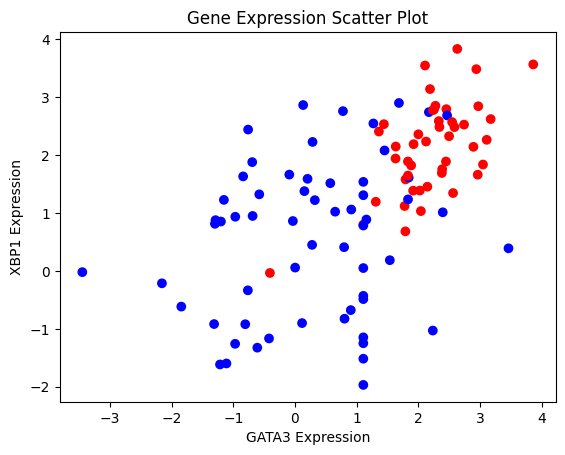

In [34]:
# Scatter plot of GATA3 vs XBP1 expression levels
plt.scatter(gata3_expression, xbp1_expression, c=colors, cmap='viridis')
plt.xlabel('GATA3 Expression')
plt.ylabel('XBP1 Expression')
plt.title('Gene Expression Scatter Plot')
plt.show()

In [35]:
# Combine GATA3 and XBP1 expression levels into a matrix
expression_matrix = np.column_stack((gata3_expression, xbp1_expression))

# Perform PCA
eigenvectors, eigenvalues, centered_data = perform_pca(expression_matrix)

# Select the first two principal components
pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

# Project data onto the principal components
pc1_projection = np.dot(centered_data, pc1)
pc2_projection = np.dot(centered_data, pc2)

# Adjust direction of PC1 if necessary
if np.mean(pc1_projection[labels == 1]) < np.mean(pc1_projection[labels == 0]):
    pc1 = -pc1
    pc1_projection = -pc1_projection

C:\Users\parth\AppData\Local\Temp\ipykernel_5136\1893780472.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(gata3_expression, xbp1_expression, c=colors, cmap='plasma')


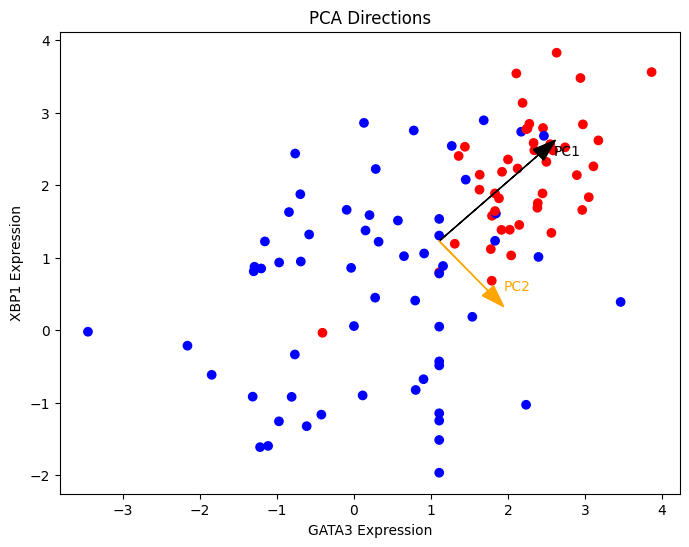

In [41]:
# Plot PCA directions on the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(gata3_expression, xbp1_expression, c=colors, cmap='plasma')

# Compute means for arrows
mean_gata3 = np.mean(gata3_expression)
mean_xbp1 = np.mean(xbp1_expression)
scale_pc1 = np.sqrt(eigenvalues[0])
scale_pc2 = np.sqrt(eigenvalues[1])

plt.arrow(mean_gata3, mean_xbp1, pc1[0]*scale_pc1, pc1[1]*scale_pc1, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(mean_gata3, mean_xbp1, pc2[0]*scale_pc2, pc2[1]*scale_pc2, head_width=0.2, head_length=0.3, fc='orange', ec='orange')

plt.text(mean_gata3 + pc1[0]*scale_pc1 + 0.2, mean_xbp1 + pc1[1]*scale_pc1, 'PC1', color='black')
plt.text(mean_gata3 + pc2[0]*scale_pc2 + 0.2, mean_xbp1 + pc2[1]*scale_pc2, 'PC2', color='orange')

plt.xlabel('GATA3 Expression')
plt.ylabel('XBP1 Expression')
plt.title('PCA Directions')
plt.show()

C:\Users\parth\AppData\Local\Temp\ipykernel_5136\2639807074.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(pc1_projection, np.zeros_like(pc1_projection), c=colors, cmap='coolwarm')


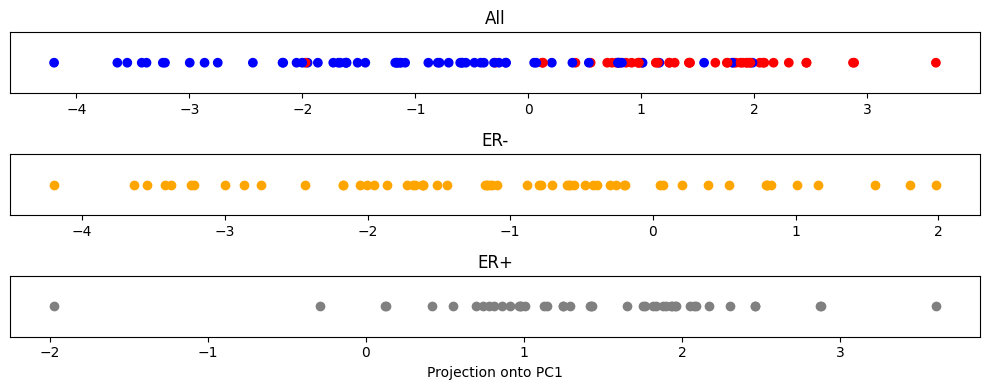

Variance explained by PC1: 0.7792
Variance explained by PC2: 0.2208


In [43]:
# Projection on PC1

# Separate ER+ and ER- samples
er_pos_pc1 = pc1_projection[labels == 1]
er_neg_pc1 = pc1_projection[labels == 0]

plt.figure(figsize=(10, 4))

# All samples
plt.subplot(3, 1, 1)
plt.scatter(pc1_projection, np.zeros_like(pc1_projection), c=colors, cmap='coolwarm')
plt.yticks([])
plt.title('All')

# ER- samples
plt.subplot(3, 1, 2)
plt.scatter(er_neg_pc1, np.zeros_like(er_neg_pc1), c='orange')
plt.yticks([])
plt.title('ER-')

# ER+ samples
plt.subplot(3, 1, 3)
plt.scatter(er_pos_pc1, np.zeros_like(er_pos_pc1), c='grey')
plt.yticks([])
plt.title('ER+')
plt.xlabel('Projection onto PC1')

plt.tight_layout()
plt.show()

# Calculate and print variance explained
print(f"Variance explained by PC1: {eigenvalues[0]/sum(eigenvalues):.4f}")
print(f"Variance explained by PC2: {eigenvalues[1]/sum(eigenvalues):.4f}")


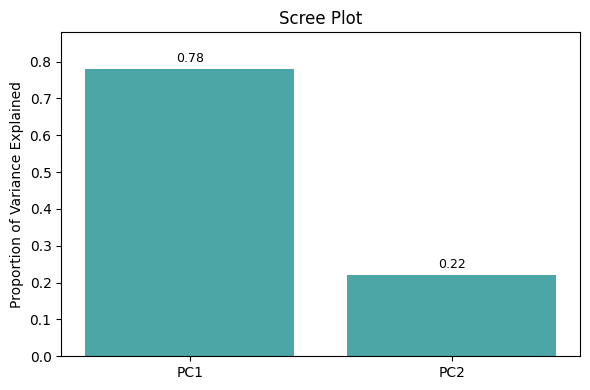

In [38]:
variance_ratio = eigenvalues / np.sum(eigenvalues)

plt.figure(figsize=(6, 4))
pca_components = [f"PC{i+1}" for i in range(len(variance_ratio))]
plt.bar(pca_components, variance_ratio, alpha=0.7, color='teal')
for i, v in enumerate(variance_ratio):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=9, color='black')

plt.ylabel('Proportion of Variance Explained')
plt.title('Scree Plot')
plt.ylim(0, max(variance_ratio) + 0.1)
plt.tight_layout()
plt.show()

### Summary of PCA Results
- PCA effectively reduced the dimensionality of the dataset while preserving key patterns.
- The scatter plot of GATA3 vs XBP1 expression levels shows clear separation between ER+ and ER- samples.
- The first principal component (PC1) captures the majority of the variance, highlighting its importance in distinguishing between the two cancer subtypes.
- PCA provides a powerful tool for visualizing and analyzing high-dimensional gene expression data.